# Timepix3-style clustering demo

This notebook builds a synthetic `x`, `y`, `time` dataframe with 50,000 input pixels, then uses `clusterer.py` to group pixels into events. The simulated data includes many compact particle-like tracks, one bridge pixel that merges two partial clusters, and isolated noise hits.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from clusterer import cluster_dataframe, cluster_pixels

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Simulate pixel hits

Each row is one hit with integer detector coordinates and a time of arrival in ns. Pixels within one event are spatially 8-connected and have nearby timestamps.

In [13]:
N_PIXELS = 10_000_000
N_TRACKS = 200_000
TRACK_PIXELS = 45
DETECTOR_SIZE = 256
TIME_SPACING_NS = 5_000


def add_track(rows, event_name, start_xy, steps, start_time_ns, dt_ns=35, jitter_ns=8):
    x, y = start_xy
    for step, (dx, dy) in enumerate(steps):
        x += dx
        y += dy
        rows.append({
            "x": int(np.clip(x, 0, DETECTOR_SIZE - 1)),
            "y": int(np.clip(y, 0, DETECTOR_SIZE - 1)),
            "time": float(start_time_ns + step * dt_ns + rng.normal(0, jitter_ns)),
            "truth": event_name,
        })


def random_walk_steps(n_steps):
    choices = np.array([
        [-1, -1], [-1, 0], [-1, 1],
        [0, -1], [0, 1],
        [1, -1], [1, 0], [1, 1],
    ])
    return [tuple(step) for step in choices[rng.integers(0, len(choices), size=n_steps)]]


rows = []

# Many compact tracks. Each one is spatially connected and lasts less than 2000 ns.
for track_id in range(N_TRACKS):
    start_xy = tuple(rng.integers(20, DETECTOR_SIZE - 20, size=2))
    start_time_ns = 10_000 + track_id * TIME_SPACING_NS
    add_track(
        rows,
        f"track_{track_id:04d}",
        start_xy,
        [(0, 0), *random_walk_steps(TRACK_PIXELS - 1)],
        start_time_ns,
    )

# Two partial clusters that become one event when the middle pixel arrives.
bridge_time_ns = 10_000 + (N_TRACKS + 4) * TIME_SPACING_NS
add_track(rows, "bridge_event", (130, 30), [(0, 0), (1, 0)], bridge_time_ns)
add_track(rows, "bridge_event", (133, 30), [(0, 0), (1, 0)], bridge_time_ns + 60)
rows.append({"x": 132, "y": 30, "time": bridge_time_ns + 120.0, "truth": "bridge_event"})

# Isolated noise-like hits. These usually become single-pixel events.
n_noise = N_PIXELS - len(rows)
for i in range(n_noise):
    rows.append({
        "x": int(rng.integers(0, DETECTOR_SIZE)),
        "y": int(rng.integers(0, DETECTOR_SIZE)),
        "time": float(rng.uniform(5_000, bridge_time_ns + 20_000)),
        "truth": "noise",
    })

df = pd.DataFrame(rows).sample(frac=1, random_state=3).reset_index(drop=True)
assert len(df) == N_PIXELS
df.head(10)

,x,y,time,truth
0,53,12,3.885761e+08,track_77713
1,215,209,1.545212e+08,track_30902
2,213,36,1.356411e+08,track_27126
3,46,87,8.346356e+08,track_166925
4,59,190,3.106109e+08,track_62120
5,204,70,7.772163e+08,track_155441
6,183,67,8.598664e+08,track_171971
7,31,193,6.023710e+08,track_120472
8,228,177,5.826753e+08,track_116533
9,137,52,5.100101e+08,track_102000


## Cluster the pixels

The default `time_window_ns=2000` follows the conservative value used in the paper. Offline data is sorted by time before clustering.

In [14]:
started = perf_counter()
clustered, events = cluster_dataframe(
    df,
    x_col="x",
    y_col="y",
    time_col="time",
    time_window_ns=2_000,
)
elapsed_s = perf_counter() - started

print(f"input pixels: {len(clustered)}")
print(f"clustered events: {len(events)}")
print(f"elapsed: {elapsed_s:.2f} s")

event_summary = pd.DataFrame({
    "cluster_id": [event.id for event in events],
    "n_pixels": [event.size for event in events],
    "min_time_ns": [event.min_time_ns for event in events],
    "max_time_ns": [event.max_time_ns for event in events],
    "duration_ns": [event.duration_ns for event in events],
})

event_summary.describe()

input pixels: 10000000
clustered events: 1199075
elapsed: 187.15 s


,cluster_id,n_pixels,min_time_ns,max_time_ns,duration_ns
count,1.199075e+06,1.199075e+06,1.199075e+06,1.199075e+06,1.199075e+06
mean,5.995370e+05,8.339762e+00,5.002613e+08,5.002616e+08,2.573274e+02
std,3.461433e+05,1.640036e+01,2.887091e+08,2.887091e+08,5.746398e+02
min,0.000000e+00,1.000000e+00,5.312381e+03,5.312381e+03,0.000000e+00
25%,2.997685e+05,1.000000e+00,2.500575e+08,2.500575e+08,0.000000e+00
50%,5.995370e+05,1.000000e+00,5.003718e+08,5.003718e+08,0.000000e+00
75%,8.993055e+05,1.000000e+00,7.505014e+08,7.505022e+08,0.000000e+00
max,1.199074e+06,4.600000e+01,1.000050e+09,1.000050e+09,1.999881e+03


In [15]:
event_summary.sort_values("n_pixels", ascending=False).head(20)

,cluster_id,n_pixels,min_time_ns,max_time_ns,duration_ns
1011864,1011864,46,8.438798e+08,8.438815e+08,1743.684623
999612,999612,46,8.337400e+08,8.337415e+08,1524.543942
13944,13944,46,1.177501e+07,1.177654e+07,1529.227327
810763,810763,46,6.766300e+08,6.766315e+08,1544.271902
763004,763004,46,6.369450e+08,6.369466e+08,1540.574506
825914,825914,46,6.892900e+08,6.892915e+08,1532.071214
913868,913868,46,7.624950e+08,7.624966e+08,1563.076074
1158955,1158955,46,9.667750e+08,9.667766e+08,1651.351281
1122376,1122376,46,9.360946e+08,9.360965e+08,1970.168501
922609,922609,46,7.698500e+08,7.698515e+08,1549.165075


## Visualize the reconstructed events

This plots all 50,000 pixels. Labels are added only for the largest reconstructed events so the plot remains readable.

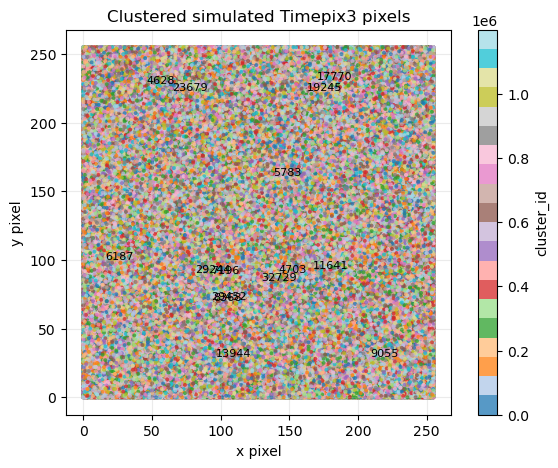

In [16]:
fig, ax = plt.subplots()
scatter = ax.scatter(
    clustered["x"],
    clustered["y"],
    c=clustered["cluster_id"],
    cmap="tab20",
    s=8,
    alpha=0.75,
    linewidth=0,
)

largest_events = sorted(events, key=lambda event: event.size, reverse=True)[:15]
for event in largest_events:
    xs = [pixel["x"] for pixel in event.pixels]
    ys = [pixel["y"] for pixel in event.pixels]
    ax.text(np.mean(xs), np.mean(ys) + 2.0, str(event.id), ha="center", fontsize=8)

ax.set_title("Clustered simulated Timepix3 pixels")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
ax.set_aspect("equal", adjustable="box")
plt.colorbar(scatter, ax=ax, label="cluster_id")
plt.show()

## Check against the simulation labels

The `truth` column is only for this synthetic example. It makes it easy to see which generated hits landed in each reconstructed cluster.

In [17]:
truth_check = (
    clustered
    .groupby("cluster_id")
    .agg(
        n_pixels=("x", "size"),
        truth_labels=("truth", lambda values: ", ".join(sorted(set(values)))),
        time_span_ns=("time", lambda values: values.max() - values.min()),
    )
    .reset_index()
)

truth_check.sort_values("n_pixels", ascending=False).head(25)

,cluster_id,n_pixels,truth_labels,time_span_ns
1011864,1011864,46,"noise, track_168774",1743.684623
999612,999612,46,"noise, track_166746",1524.543942
13944,13944,46,"noise, track_2353",1529.227327
810763,810763,46,"noise, track_135324",1544.271902
763004,763004,46,"noise, track_127387",1540.574506
825914,825914,46,"noise, track_137856",1532.071214
913868,913868,46,"noise, track_152497",1563.076074
1158955,1158955,46,"noise, track_193353",1651.351281
1122376,1122376,46,"noise, track_187217",1970.168501
922609,922609,46,"noise, track_153968",1549.165075


## Try a stricter time window

A smaller window can split tracks whose pixels are spatially connected but spread too far in time.

In [18]:
strict_clustered, strict_events = cluster_dataframe(
    df,
    time_window_ns=120,
)

pd.DataFrame({
    "setting": ["default 2000 ns", "strict 120 ns"],
    "events": [len(events), len(strict_events)],
    "multi_pixel_events": [
        sum(event.size > 1 for event in events),
        sum(event.size > 1 for event in strict_events),
    ],
})

,setting,events,multi_pixel_events
0,default 2000 ns,1199075,200483
1,strict 120 ns,3360687,2279328


In [28]:
test_df = pd.DataFrame()
test_df["x"] = [50, 50, 50, 51, 51, 51, 52, 52, 52]
test_df["y"] = [30, 31, 32, 33, 34, 35, 33, 34, 35]
test_df["time"] = [1000, 1010, 1020, 1100, 1110, 1120, 1150, 1160, 1000]

test_df = test_df.sort_values("time").reset_index(drop=True)
test_clustered, test_events = cluster_dataframe(
    test_df,
    x_col="x",
    y_col="y",
    time_col="time",
)


In [29]:
test_clustered

,x,y,time,cluster_id
0,50,30,1000,0
1,52,35,1000,0
2,50,31,1010,0
3,50,32,1020,0
4,51,33,1100,0
5,51,34,1110,0
6,51,35,1120,0
7,52,33,1150,0
8,52,34,1160,0
